<a href="https://colab.research.google.com/github/ANANTHA1628/mesin-learning-/blob/main/js4_praktikum%203.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
	# Mengimpor library
	import numpy as np
	import matplotlib.pyplot as plt
	import pandas as pd

In [ ]:
from sklearn.preprocessing import StandardScaler

In [ ]:
	# Mengimpor dataset (Pastikan Anda memiliki file CSV 'Posisi_gaji.csv' dalam direktori yang sama)
	dataset = pd.read_csv('Posisi_gaji.csv')
	X = dataset.iloc[:, 1:2].values
	y = dataset.iloc[:, 2].values  # Ubah menjadi satu kolom saja

In [ ]:
# Penskalaan fitur (StandardScaler)
sc_X = StandardScaler()
sc_y = StandardScaler()
X_scaled = sc_X.fit_transform(X)
y_scaled = sc_y.fit_transform(y.reshape(-1, 1))

In [ ]:
from sklearn.svm import SVR
regressor = SVR(kernel='rbf')
regressor.fit(X_scaled, y_scaled.ravel())

SVR()

/tmp/ipykernel_3935/4265118611.py:1: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  X_grid = np.arange(min(X), max(X), 0.01).reshape(-1, 1)


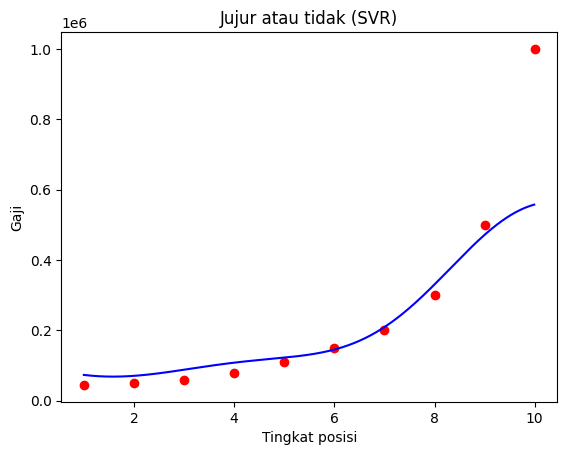

In [ ]:
X_grid = np.arange(min(X), max(X), 0.01).reshape(-1, 1)

# Penskalaan X_grid sebelum prediksi
X_grid_scaled = sc_X.transform(X_grid)

# Prediksi dengan model SVR
y_pred_scaled = regressor.predict(X_grid_scaled)

# Mengembalikan hasil prediksi ke skala asli
y_pred_plot = sc_y.inverse_transform(y_pred_scaled.reshape(-1, 1))

plt.scatter(X, y, color='red')
plt.plot(X_grid, y_pred_plot, color='blue')
plt.title('Jujur atau tidak (SVR)')
plt.xlabel('Tingkat posisi')
plt.ylabel('Gaji')
plt.show()

In [ ]:
# Prediksi hasil
# Buat array 2D yang berisi tingkat posisi yang akan diprediksi
tingkat_posisi_prediksi = np.array([[6.5]])

# Penskalaan fitur untuk data yang akan diprediksi
tingkat_posisi_prediksi_scaled = sc_X.transform(tingkat_posisi_prediksi)

# Melakukan prediksi menggunakan model SVR
gaji_prediksi_scaled = regressor.predict(tingkat_posisi_prediksi_scaled)

# Kembalikan hasil prediksi ke skala aslinya
gaji_prediksi = sc_y.inverse_transform(gaji_prediksi_scaled.reshape(-1, 1))

In [ ]:
	# Menampilkan hasil prediksi
	print("Prediksi Gaji untuk Tingkat Posisi 6.5:", gaji_prediksi[0])

Prediksi Gaji untuk Tingkat Posisi 6.5: [170370.0204065]


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

y_actual = y

# Prediksi pada X yang sudah di-scaled, lalu inverse transform hasilnya
y_pred_scaled = regressor.predict(sc_X.transform(X))
y_pred = sc_y.inverse_transform(y_pred_scaled.reshape(-1, 1))

# Menghitung MAE
mae = mean_absolute_error(y_actual, y_pred)

# Menghitung MSE
mse = mean_squared_error(y_actual, y_pred)

# Menghitung RMSE
rmse = np.sqrt(mse)

# Menghitung R-squared
r2 = r2_score(y_actual, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R-squared:", r2)

MAE: 63332.392089689674
MSE: 20036494264.13176
RMSE: 141550.3241399742
R-squared: 0.7516001070620797
